# Modélisation Random Forest — Classification des alertes cybersécurité Microsoft

**Branche :** `Guyjc-Modélisation`  
**Auteur :** Guy Junior Calvet  
**Objectif :** Construire un modèle Random Forest optimisé pour classifier les incidents de sécurité Microsoft en 3 classes : `BenignPositive`, `FalsePositive`, `TruePositive`, et comparer ses performances avec le modèle KNN.

### Architecture
Le **prétraitement et l'exploration des données** sont réalisés dans `notebook.ipynb` (branche `main`). Ce fichier exporte un CSV prétraité (`donnees_preprocessees.csv`) que le présent notebook charge directement pour la **modélisation**.

### Pipeline de modélisation
1. **Chargement des données prétraitées** via `donnees_preprocessees.csv`
2. **Modèle RF de base** (baseline avec paramètres par défaut)
3. **Analyse de l'importance des features**
4. **Optimisation par RandomizedSearchCV** (hyperparamètres)
5. **Évaluation finale** et comparaison avec KNN

### Pourquoi Random Forest après KNN ?
Les résultats KNN (Macro F1 ≈ 0.582) montrent des limites liées à :
- La **malédiction de la dimensionnalité** (173 features après OHE)
- La **sensibilité au déséquilibre** des classes (`FalsePositive` recall ≈ 0.30)
- Le **calcul de distances** sur des features majoritairement binaires (OHE)

Random Forest corrige ces faiblesses grâce à :
- Des **splits binaires** insensibles à la dimensionnalité
- Le paramètre `class_weight='balanced'` pour le déséquilibre
- La **sélection automatique** des features discriminantes

### Sources & Références
- Breiman, L. (2001). *Random Forests*. Machine Learning, 45(1), 5-32.
- Fernández-Delgado, M. et al. (2014). *Do we need hundreds of classifiers?* JMLR, 15, 3133-3181.
- Scikit-learn Random Forest : https://scikit-learn.org/stable/modules/ensemble.html#forests-of-randomized-trees
- Dataset GUIDE : https://www.kaggle.com/datasets/Microsoft/microsoft-security-incident-prediction
- Scikit-learn RandomizedSearchCV : https://scikit-learn.org/stable/modules/grid_search.html#randomized-parameter-optimization
- Notes de cours (Forage des données et Analyse statistiques des données de masse)

## 1. Importation des bibliothèques

In [1]:
# ── Bibliothèques standard ──
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# ── Scikit-learn : modélisation ──
from sklearn.model_selection import (
    train_test_split, cross_val_score,
    RandomizedSearchCV, StratifiedKFold
)
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestClassifier

# ── Scikit-learn : métriques ──
from sklearn.metrics import (
    classification_report, confusion_matrix,
    ConfusionMatrixDisplay, accuracy_score, f1_score,
    precision_score, recall_score
)

# -- Constantes --
# Cible binaire (nouveau pretraitement equipe) : 0 = Non-TP, 1 = TP
CIBLE_MAP = {'Non-TruePositive': 0, 'TruePositive': 1}
CIBLE_MAP_INV = {v: k for k, v in CIBLE_MAP.items()}
TARGET_NAMES = ['Non-TP (0)', 'TP (1)']

print("Bibliotheques importees avec succes.")

Bibliotheques importees avec succes.


## 2. Chargement des données prétraitées et transformation

Les données ont été **prétraitées et explorées** dans `notebook.ipynb` (branche `main`) et sauvegardées dans `donnees_preprocessees.csv`.

> **Note :** Contrairement à KNN, Random Forest **ne nécessite pas de scaling** (les arbres sont invariants aux transformations monotones). Cependant, on applique tout de même le `OneHotEncoder` pour les variables catégorielles, et le `StandardScaler` pour cohérence avec le pipeline KNN et pour permettre une comparaison équitable.

In [2]:
# ── 2.1 Chargement du dataset prétraité ──
df = pd.read_csv("donnees_preprocessees.csv", low_memory=False)
print(f"Dimensions : {df.shape[0]:,} lignes × {df.shape[1]} colonnes")

# Séparation X / y
X = df.drop(columns=['cible'])
y = df['cible']

# Identifier les colonnes numériques et catégorielles
num_cols = X.select_dtypes(exclude='object').columns.tolist()
cat_cols = X.select_dtypes(include='object').columns.tolist()
for col in cat_cols:
    X[col] = X[col].astype(str)

print(f"\n  Numériques    ({len(num_cols)}) : {num_cols}")
print(f"  Catégorielles ({len(cat_cols)}) : {cat_cols}")
print(f"\n  Distribution cible :")
print(y.map(CIBLE_MAP_INV).value_counts().to_string())

# ── 2.2 Split stratifié (80/20) — même seed que KNN pour comparaison équitable ──
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=2026, stratify=y
)
print(f"\n  Train : {X_train.shape[0]:,}  |  Test : {X_test.shape[0]:,}")

# ── 2.3 Transformation (StandardScaler + OneHotEncoder) ──
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), num_cols),
        ('cat', OneHotEncoder(drop='first', handle_unknown='ignore',
                              sparse_output=False), cat_cols),
    ]
)

X_train_transformed = preprocessor.fit_transform(X_train)
X_test_transformed  = preprocessor.transform(X_test)

print(f"\n  Dimensionnalité après OneHotEncoding : {X_train_transformed.shape[1]} features")
print(f"  Train : {X_train_transformed.shape}  |  Test : {X_test_transformed.shape}")

Dimensions : 94,638 lignes × 21 colonnes

  Numériques    (6) : ['RegistryValueData', 'OSFamily', 'OSVersion', 'Month', 'IsWeekend', 'IsBusinessHour']
  Catégorielles (14) : ['AlertTitle', 'Category', 'MitreTechniques', 'ActionGrouped', 'ActionGranular', 'EntityType', 'ThreatFamily', 'ResourceType', 'Roles', 'EvidenceRole', 'AntispamDirection', 'SuspicionLevel', 'LastVerdict', 'CountryCode']

  Distribution cible :
cible
Non-TruePositive    61418
TruePositive        33220

  Train : 75,710  |  Test : 18,928

  Dimensionnalité après OneHotEncoding : 185 features
  Train : (75710, 185)  |  Test : (18928, 185)

  Dimensionnalité après OneHotEncoding : 185 features
  Train : (75710, 185)  |  Test : (18928, 185)


## 3. Modèle Random Forest Baseline

On commence par un modèle RF avec les **paramètres par défaut** de scikit-learn, plus `class_weight='balanced'` pour gérer le déséquilibre des classes, et `random_state=2026` pour la reproductibilité.

### Rappel théorique : Random Forest
Un Random Forest est un **ensemble de $B$ arbres de décision** entraînés sur des sous-échantillons bootstrap, avec une sélection aléatoire de $m$ features à chaque split :

$$\hat{y}(x) = \text{mode}\left\{\hat{y}_b(x)\right\}_{b=1}^{B}$$

où chaque arbre $\hat{y}_b$ vote pour une classe, et la prédiction finale est le **vote majoritaire**.

### Avantages clés
- **Bagging** : réduit la variance sans augmenter le biais (Breiman, 2001)
- **Feature subsampling** : décorrèle les arbres → meilleure généralisation
- **`class_weight='balanced'`** : pondère chaque classe par $\frac{N}{K \cdot n_k}$ où $n_k$ est l'effectif de la classe $k$

In [3]:
# ── 3.1 Random Forest Baseline ──
# Paramètres par défaut + class_weight='balanced' pour gérer le déséquilibre

rf_baseline = RandomForestClassifier(
    n_estimators=100,           # 100 arbres (défaut scikit-learn)
    class_weight='balanced',    # pondération automatique des classes
    random_state=2026,
    n_jobs=-1
)

rf_baseline.fit(X_train_transformed, y_train)
y_pred_baseline = rf_baseline.predict(X_test_transformed)

# Métriques baseline
acc_baseline = accuracy_score(y_test, y_pred_baseline)
f1_baseline  = f1_score(y_test, y_pred_baseline, average='macro')

print("=" * 65)
print("        RANDOM FOREST BASELINE (100 arbres, balanced)")
print("=" * 65)
print(f"\n  Accuracy  : {acc_baseline:.4f}")
print(f"  Macro F1  : {f1_baseline:.4f}")
print(f"\n{'─' * 65}")
print("\nRapport de classification :")
print(classification_report(
    y_test, y_pred_baseline,
    target_names=TARGET_NAMES
))

        RANDOM FOREST BASELINE (100 arbres, balanced)

  Accuracy  : 0.7748
  Macro F1  : 0.7615

─────────────────────────────────────────────────────────────────

Rapport de classification :
              precision    recall  f1-score   support

  Non-TP (0)       0.86      0.78      0.82     12284
      TP (1)       0.65      0.77      0.71      6644

    accuracy                           0.77     18928
   macro avg       0.76      0.77      0.76     18928
weighted avg       0.79      0.77      0.78     18928



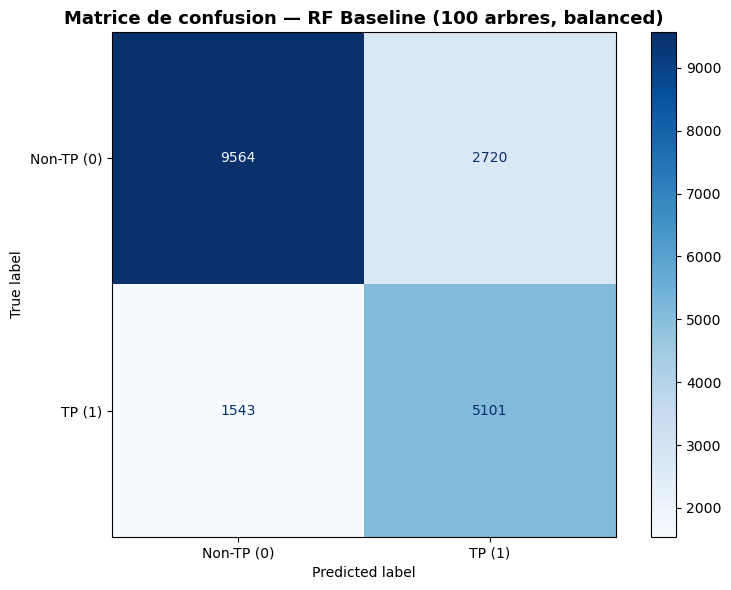

In [4]:
# ── 3.2 Matrice de confusion — Baseline ──
fig, ax = plt.subplots(figsize=(8, 6))
ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred_baseline,
    display_labels=TARGET_NAMES,
    cmap='Blues', ax=ax
)
ax.set_title('Matrice de confusion — RF Baseline (100 arbres, balanced)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## 4. Importance des features

Un avantage majeur de Random Forest est la capacité à mesurer l'**importance de chaque feature** via la diminution moyenne d'impureté (MDI — Mean Decrease in Impurity).

$$\text{Importance}(X_j) = \frac{1}{B} \sum_{b=1}^{B} \sum_{t \in T_b} \Delta i(t) \cdot \mathbb{1}(X_j \text{ est la variable de split au nœud } t)$$

Cela permet d'identifier quelles variables contribuent le plus à la classification, ce que KNN ne pouvait pas offrir.

In [5]:
# ── 4.1 Extraction des noms de features après transformation ──

# Récupérer les noms de features du ColumnTransformer
feature_names_num = num_cols
feature_names_cat = preprocessor.named_transformers_['cat'].get_feature_names_out(cat_cols).tolist()
feature_names_all = feature_names_num + feature_names_cat

# Importance des features
importances = rf_baseline.feature_importances_
indices = np.argsort(importances)[::-1]

# Top 25 features
top_n = 25
print(f"Top {top_n} features les plus importantes :\n")
for i in range(top_n):
    print(f"  {i+1:2d}. {feature_names_all[indices[i]]:<40s} → {importances[indices[i]]:.4f}")

print(f"\n  Importance cumulée (top {top_n}) : "
      f"{importances[indices[:top_n]].sum()*100:.1f}%")

Top 25 features les plus importantes :

   1. Category_InitialAccess                   → 0.0904
   2. AlertTitle_Other                         → 0.0736
   3. Category_Exfiltration                    → 0.0641
   4. MitreTechniques_T1078                    → 0.0611
   5. CountryCode_242                          → 0.0469
   6. AlertTitle_3                             → 0.0412
   7. AlertTitle_6                             → 0.0365
   8. EntityType_CloudLogonRequest             → 0.0340
   9. IsBusinessHour                           → 0.0259
  10. MitreTechniques_Unknown                  → 0.0235
  11. IsWeekend                                → 0.0227
  12. EntityType_Machine                       → 0.0221
  13. Month                                    → 0.0218
  14. EntityType_MailMessage                   → 0.0209
  15. MitreTechniques_T1566                    → 0.0182
  16. Category_SuspiciousActivity              → 0.0179
  17. AlertTitle_20                            → 0.0160
  18. Ev

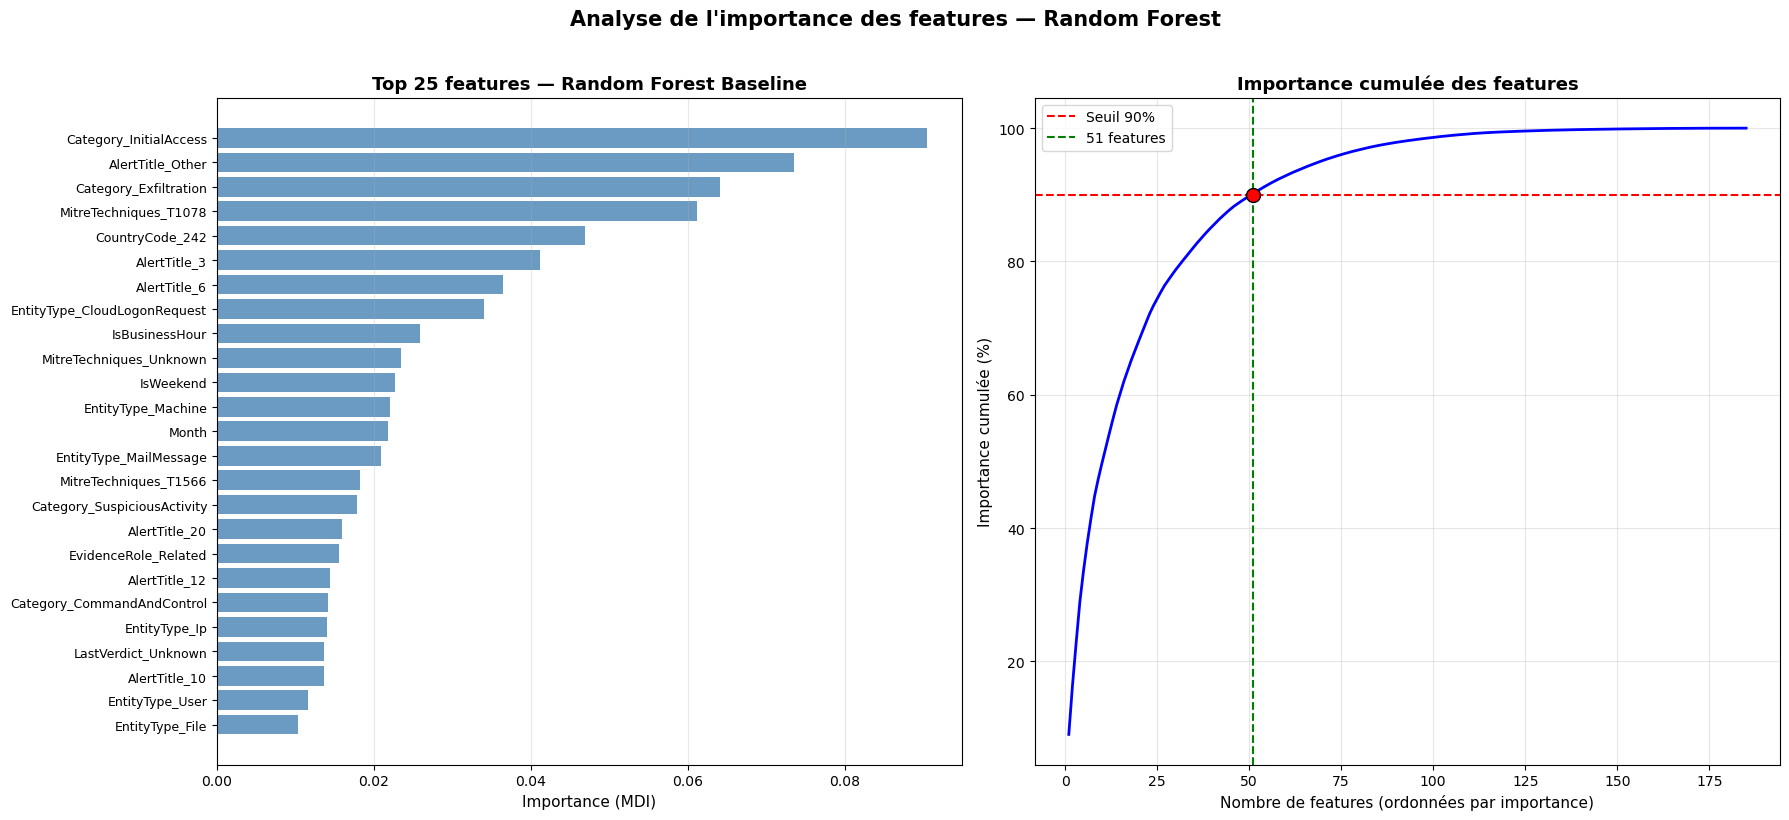


 51 features suffisent pour capter 90% de l'importance totale (sur 185 features)


In [6]:
# ── 4.2 Visualisation de l'importance des features ──

fig, axes = plt.subplots(1, 2, figsize=(18, 8))

# --- Graphique 1 : Top 25 features ---
top_idx = indices[:top_n]
top_names = [feature_names_all[i] for i in top_idx]
top_importances = importances[top_idx]

axes[0].barh(range(top_n), top_importances[::-1], color='steelblue', alpha=0.8)
axes[0].set_yticks(range(top_n))
axes[0].set_yticklabels(top_names[::-1], fontsize=9)
axes[0].set_xlabel('Importance (MDI)', fontsize=11)
axes[0].set_title(f'Top {top_n} features — Random Forest Baseline',
                  fontsize=13, fontweight='bold')
axes[0].grid(axis='x', alpha=0.3)

# --- Graphique 2 : Importance cumulée ---
cum_importance = np.cumsum(importances[indices])
axes[1].plot(range(1, len(cum_importance) + 1), cum_importance * 100, 'b-', linewidth=2)
axes[1].axhline(y=90, color='red', linestyle='--', linewidth=1.5, label='Seuil 90%')
n_feat_90 = np.argmax(cum_importance >= 0.90) + 1
axes[1].axvline(x=n_feat_90, color='green', linestyle='--', linewidth=1.5,
                label=f'{n_feat_90} features')
axes[1].scatter([n_feat_90], [90], color='red', s=100, zorder=5, edgecolors='black')
axes[1].set_xlabel('Nombre de features (ordonnées par importance)', fontsize=11)
axes[1].set_ylabel('Importance cumulée (%)', fontsize=11)
axes[1].set_title('Importance cumulée des features', fontsize=13, fontweight='bold')
axes[1].legend(fontsize=10)
axes[1].grid(True, alpha=0.3)

plt.suptitle('Analyse de l\'importance des features — Random Forest',
             fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print(f"\n {n_feat_90} features suffisent pour capter 90% de l'importance totale "
      f"(sur {len(feature_names_all)} features)")

## 5. Optimisation par RandomizedSearchCV

### Pourquoi RandomizedSearchCV plutôt que GridSearchCV ?
Avec Random Forest, l'espace des hyperparamètres est **vaste** (nombre d'arbres × profondeur × min_samples × max_features × ...). Un GridSearchCV exhaustif serait prohibitif en temps de calcul.

**RandomizedSearchCV** échantillonne aléatoirement $n$ combinaisons dans l'espace, ce qui offre un bon compromis exploration/temps (Bergstra & Bengio, 2012).

| Hyperparamètre | Valeurs testées | Justification |
|----------------|-----------------|---------------|
| `n_estimators` | 100, 200, 300 | Nombre d'arbres dans la forêt |
| `max_depth` | 10, 20, 30, None | Profondeur maximale de chaque arbre |
| `min_samples_split` | 2, 5, 10 | Nombre min d'échantillons pour diviser un nœud |
| `min_samples_leaf` | 1, 2, 4 | Nombre min d'échantillons dans une feuille |
| `max_features` | `'sqrt'`, `'log2'` | Nombre de features considérées à chaque split |
| `class_weight` | `'balanced'`, `'balanced_subsample'` | Pondération des classes |

### Choix de 3 folds
Même justification que pour KNN : avec ~75 000 lignes d'entraînement, 3 folds offrent ~25 000 observations par fold de validation — suffisant pour une estimation stable.

In [7]:
# ── 5.1 RandomizedSearchCV — Optimisation des hyperparamètres ──
# Réf. : Bergstra & Bengio (2012). Random Search for Hyper-Parameter Optimization. JMLR.

param_distributions = {
    'n_estimators': [100, 200, 300],
    'max_depth': [10, 20, 30, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': ['sqrt', 'log2'],
    'class_weight': ['balanced', 'balanced_subsample'],
}

random_search = RandomizedSearchCV(
    estimator=RandomForestClassifier(random_state=2026, n_jobs=-1),
    param_distributions=param_distributions,
    n_iter=50,                # 50 combinaisons aléatoires
    scoring='f1_macro',
    cv=StratifiedKFold(n_splits=3, shuffle=True, random_state=2026),
    n_jobs=-1,
    verbose=1,
    random_state=2026,
    return_train_score=True
)

total_fits = 50 * 3
print(f"Combinaisons testées : 50  |  Fits totaux : {total_fits}")
print(f"\nLancement du RandomizedSearchCV...")

random_search.fit(X_train_transformed, y_train)

print(f"\n RandomizedSearchCV terminé !")
print(f"\n{'=' * 65}")
print(f"  Meilleurs hyperparamètres :")
for param, val in random_search.best_params_.items():
    print(f"    {param} = {val}")
print(f"\n  Meilleur Macro F1 (CV) : {random_search.best_score_:.4f}")
print(f"{'=' * 65}")

Combinaisons testées : 50  |  Fits totaux : 150

Lancement du RandomizedSearchCV...
Fitting 3 folds for each of 50 candidates, totalling 150 fits

 RandomizedSearchCV terminé !

  Meilleurs hyperparamètres :
    n_estimators = 300
    min_samples_split = 2
    min_samples_leaf = 2
    max_features = log2
    max_depth = None
    class_weight = balanced_subsample

  Meilleur Macro F1 (CV) : 0.7640

 RandomizedSearchCV terminé !

  Meilleurs hyperparamètres :
    n_estimators = 300
    min_samples_split = 2
    min_samples_leaf = 2
    max_features = log2
    max_depth = None
    class_weight = balanced_subsample

  Meilleur Macro F1 (CV) : 0.7640


In [8]:
# ── 5.2 Résultats détaillés du RandomizedSearchCV ──

results_df = pd.DataFrame(random_search.cv_results_)

cols_display = ['param_n_estimators', 'param_max_depth', 'param_max_features',
                'param_class_weight', 'mean_test_score', 'std_test_score',
                'mean_train_score', 'rank_test_score']
results_display = (
    results_df[cols_display]
    .sort_values('rank_test_score')
    .head(15)
    .reset_index(drop=True)
)
results_display.columns = ['n_estimators', 'max_depth', 'max_features',
                           'class_weight', 'F1 Test (CV)', 'Std Test',
                           'F1 Train (CV)', 'Rang']

print("Top 15 des combinaisons d'hyperparamètres :\n")
print(results_display.to_string(index=False))

# Vérification du surapprentissage
best_train = results_df.loc[results_df['rank_test_score'] == 1, 'mean_train_score'].values[0]
best_test  = random_search.best_score_
gap = best_train - best_test
print(f"\n Écart Train-Test (meilleur modèle) : {gap:.4f}")
if gap > 0.05:
    print("   Écart significatif → risque de surapprentissage")
else:
    print("   Écart acceptable → pas de surapprentissage majeur")

Top 15 des combinaisons d'hyperparamètres :

 n_estimators max_depth max_features       class_weight  F1 Test (CV)  Std Test  F1 Train (CV)  Rang
          300      None         log2 balanced_subsample      0.763974  0.001848       0.774558     1
          300        20         sqrt           balanced      0.763535  0.002624       0.771128     2
          200        30         log2 balanced_subsample      0.763466  0.002504       0.774138     3
          100      None         log2 balanced_subsample      0.763189  0.002505       0.773588     4
          200        30         log2           balanced      0.763137  0.001964       0.773687     5
          300        20         log2           balanced      0.762919  0.001497       0.774791     6
          200        20         sqrt balanced_subsample      0.762604  0.001119       0.770800     7
          300        20         log2           balanced      0.762584  0.001177       0.775596     8
          100        30         log2 balanced_

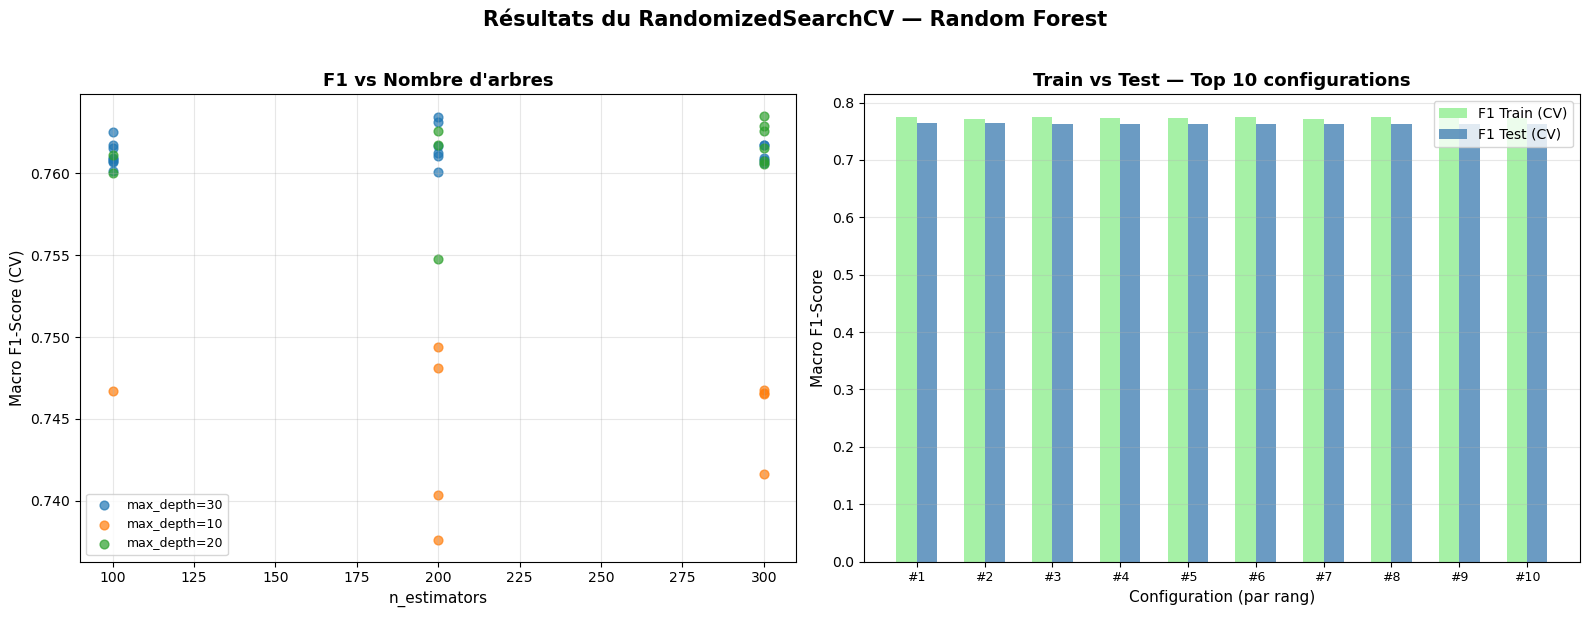

In [9]:
# ── 5.3 Visualisation — Impact des hyperparamètres ──

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# --- Graphique 1 : F1 vs n_estimators ---
for depth in results_df['param_max_depth'].unique():
    mask = results_df['param_max_depth'] == depth
    subset = results_df[mask].sort_values('param_n_estimators')
    if len(subset) > 1:
        axes[0].scatter(
            subset['param_n_estimators'].astype(float),
            subset['mean_test_score'],
            label=f'max_depth={depth}', alpha=0.7, s=40
        )

axes[0].set_xlabel('n_estimators', fontsize=11)
axes[0].set_ylabel('Macro F1-Score (CV)', fontsize=11)
axes[0].set_title('F1 vs Nombre d\'arbres', fontsize=13, fontweight='bold')
axes[0].legend(fontsize=9)
axes[0].grid(True, alpha=0.3)

# --- Graphique 2 : Train vs Test (top configs) ---
top_10 = results_df.sort_values('rank_test_score').head(10)
x_pos = range(len(top_10))
axes[1].bar([x - 0.15 for x in x_pos], top_10['mean_train_score'], 0.3,
            label='F1 Train (CV)', color='lightgreen', alpha=0.8)
axes[1].bar([x + 0.15 for x in x_pos], top_10['mean_test_score'], 0.3,
            label='F1 Test (CV)', color='steelblue', alpha=0.8)
axes[1].set_xlabel('Configuration (par rang)', fontsize=11)
axes[1].set_ylabel('Macro F1-Score', fontsize=11)
axes[1].set_title('Train vs Test — Top 10 configurations', fontsize=13, fontweight='bold')
axes[1].set_xticks(x_pos)
axes[1].set_xticklabels([f'#{i+1}' for i in range(len(top_10))], fontsize=9)
axes[1].legend(fontsize=10)
axes[1].grid(axis='y', alpha=0.3)

plt.suptitle('Résultats du RandomizedSearchCV — Random Forest',
             fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

## 6. Évaluation finale du modèle optimisé

On utilise le **meilleur modèle** identifié par RandomizedSearchCV pour prédire sur le **jeu de test** (jamais vu pendant l'entraînement ni la validation croisée).

### Métriques utilisées
| Métrique | Formule | Interprétation |
|----------|---------|----------------|
| **Accuracy** | $\frac{TP + TN}{Total}$ | Proportion de prédictions correctes |
| **Precision** | $\frac{TP}{TP + FP}$ | Parmi les prédits positifs, combien sont corrects |
| **Recall** | $\frac{TP}{TP + FN}$ | Parmi les vrais positifs, combien sont détectés |
| **F1-Score** | $2 \times \frac{P \times R}{P + R}$ | Moyenne harmonique Precision-Recall |
| **Macro F1** | Moyenne des F1 par classe | Traite toutes les classes de façon équitable |

In [10]:
# ── 6.1 Prédictions avec le meilleur modèle ──

best_rf = random_search.best_estimator_
y_pred_best = best_rf.predict(X_test_transformed)

# Métriques détaillées
acc_best  = accuracy_score(y_test, y_pred_best)
f1_best   = f1_score(y_test, y_pred_best, average='macro')
prec_best = precision_score(y_test, y_pred_best, average='macro')
rec_best  = recall_score(y_test, y_pred_best, average='macro')

print("=" * 65)
print("     ÉVALUATION FINALE — RANDOM FOREST OPTIMISÉ (jeu de test)")
print("=" * 65)
print(f"\n  Hyperparamètres optimaux :")
for param, val in random_search.best_params_.items():
    print(f"    {param} = {val}")
print(f"\n  Accuracy        : {acc_best:.4f}")
print(f"  Macro Precision : {prec_best:.4f}")
print(f"  Macro Recall    : {rec_best:.4f}")
print(f"  Macro F1-Score  : {f1_best:.4f}")
print(f"\n{'─' * 65}")
print("\nRapport de classification détaillé :")
print(classification_report(
    y_test, y_pred_best,
    target_names=TARGET_NAMES
))

     ÉVALUATION FINALE — RANDOM FOREST OPTIMISÉ (jeu de test)

  Hyperparamètres optimaux :
    n_estimators = 300
    min_samples_split = 2
    min_samples_leaf = 2
    max_features = log2
    max_depth = None
    class_weight = balanced_subsample

  Accuracy        : 0.7858
  Macro Precision : 0.7650
  Macro Recall    : 0.7715
  Macro F1-Score  : 0.7679

─────────────────────────────────────────────────────────────────

Rapport de classification détaillé :
              precision    recall  f1-score   support

  Non-TP (0)       0.85      0.82      0.83     12284
      TP (1)       0.68      0.72      0.70      6644

    accuracy                           0.79     18928
   macro avg       0.77      0.77      0.77     18928
weighted avg       0.79      0.79      0.79     18928



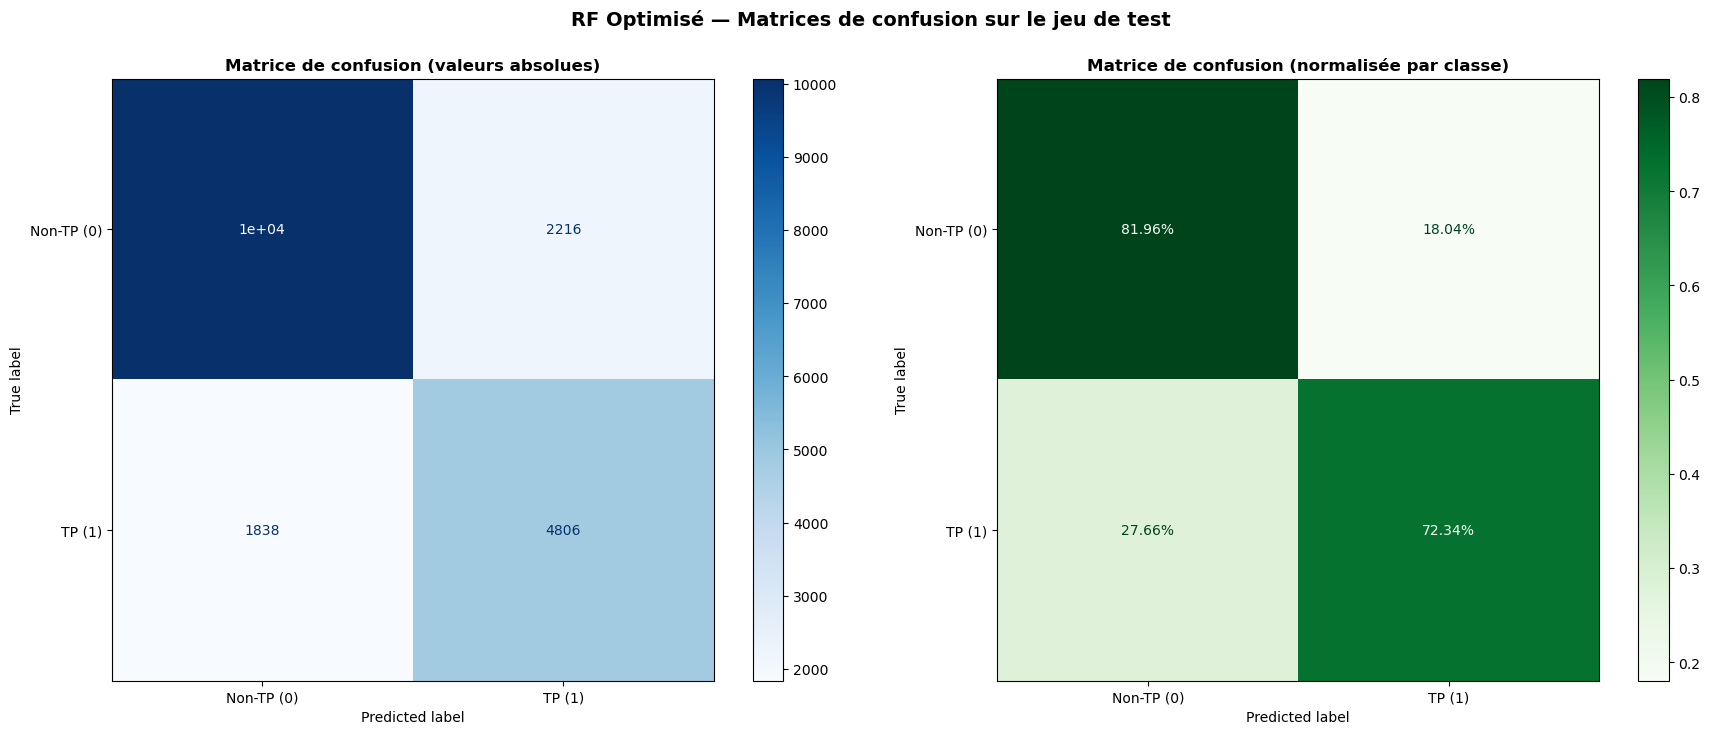

In [11]:
# ── 6.2 Matrices de confusion — Modèle optimisé ──

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred_best,
    display_labels=TARGET_NAMES,
    cmap='Blues', ax=axes[0]
)
axes[0].set_title('Matrice de confusion (valeurs absolues)', fontsize=12, fontweight='bold')

ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred_best,
    display_labels=TARGET_NAMES,
    normalize='true', cmap='Greens', values_format='.2%', ax=axes[1]
)
axes[1].set_title('Matrice de confusion (normalisée par classe)', fontsize=12, fontweight='bold')

plt.suptitle('RF Optimisé — Matrices de confusion sur le jeu de test',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

     COMPARAISON : RF BASELINE  vs  RF OPTIMISÉ
       Métrique  RF Baseline  RF Optimisé  Amélioration  Gain (%)
       Accuracy     0.774778     0.785820      0.011042      1.43
Macro Precision     0.756648     0.765022      0.008374      1.11
   Macro Recall     0.773167     0.771481     -0.001686     -0.22
 Macro F1-Score     0.761520     0.767881      0.006361      0.84


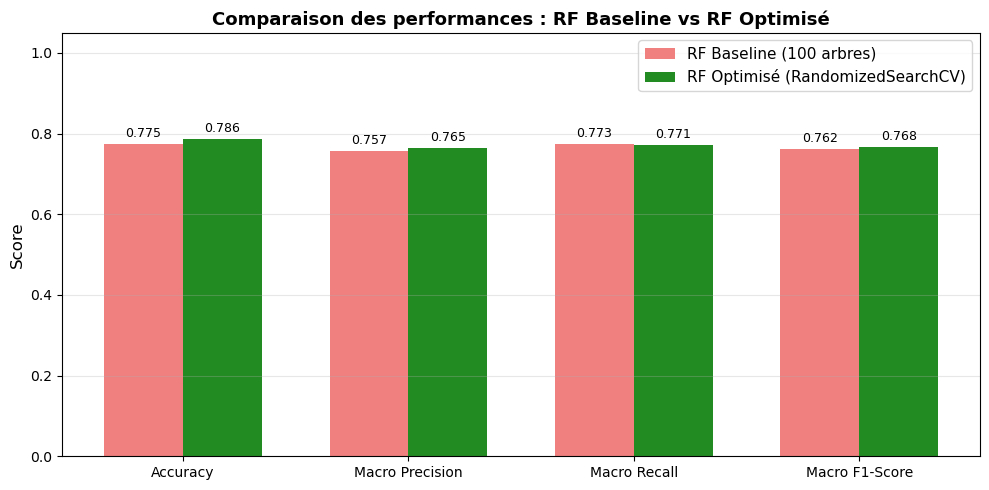

In [12]:
# ── 6.3 Comparaison : RF Baseline vs RF Optimisé ──

comparison_rf = pd.DataFrame({
    'Métrique': ['Accuracy', 'Macro Precision', 'Macro Recall', 'Macro F1-Score'],
    'RF Baseline': [
        acc_baseline,
        precision_score(y_test, y_pred_baseline, average='macro'),
        recall_score(y_test, y_pred_baseline, average='macro'),
        f1_baseline
    ],
    'RF Optimisé': [acc_best, prec_best, rec_best, f1_best]
})
comparison_rf['Amélioration'] = comparison_rf['RF Optimisé'] - comparison_rf['RF Baseline']
comparison_rf['Gain (%)'] = (comparison_rf['Amélioration'] / comparison_rf['RF Baseline'] * 100).round(2)

print("=" * 75)
print("     COMPARAISON : RF BASELINE  vs  RF OPTIMISÉ")
print("=" * 75)
print(comparison_rf.to_string(index=False))

# Visualisation
fig, ax = plt.subplots(figsize=(10, 5))
x = np.arange(len(comparison_rf))
width = 0.35

bars1 = ax.bar(x - width/2, comparison_rf['RF Baseline'], width,
               label='RF Baseline (100 arbres)', color='lightcoral')
bars2 = ax.bar(x + width/2, comparison_rf['RF Optimisé'], width,
               label='RF Optimisé (RandomizedSearchCV)', color='forestgreen')

ax.set_ylabel('Score', fontsize=12)
ax.set_title('Comparaison des performances : RF Baseline vs RF Optimisé',
             fontsize=13, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(comparison_rf['Métrique'], fontsize=10)
ax.legend(fontsize=11)
ax.set_ylim(0, 1.05)

for bars in [bars1, bars2]:
    for bar in bars:
        ax.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.01,
                f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=9)

ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

## 7. Comparaison avec le modèle KNN

### Résultats KNN (rappel)
Le modèle KNN optimisé (avec PCA) a obtenu les résultats suivants sur le **même jeu de test** (même `random_state=2026`, même split 80/20) :

| Métrique | KNN PCA + Optimisé |
|----------|--------------------|
| Accuracy | 0.6389 |
| Macro Precision | 0.6193 |
| Macro Recall | 0.5782 |
| Macro F1 | 0.5819 |

Comparons directement avec les résultats du Random Forest.

     COMPARAISON INTER-MODÈLES : KNN (PCA + Optimisé)  vs  RF Baseline  vs  RF Optimisé
       Métrique  KNN (PCA + Optimisé)  RF Baseline  RF Optimisé  Gain RF vs KNN  Gain (%)
       Accuracy                0.8007     0.774778     0.785820       -0.014880     -1.86
Macro Precision                0.7726     0.756648     0.765022       -0.007578     -0.98
   Macro Recall                0.7715     0.773167     0.771481       -0.000019     -0.00
 Macro F1-Score                0.7714     0.761520     0.767881       -0.003519     -0.46


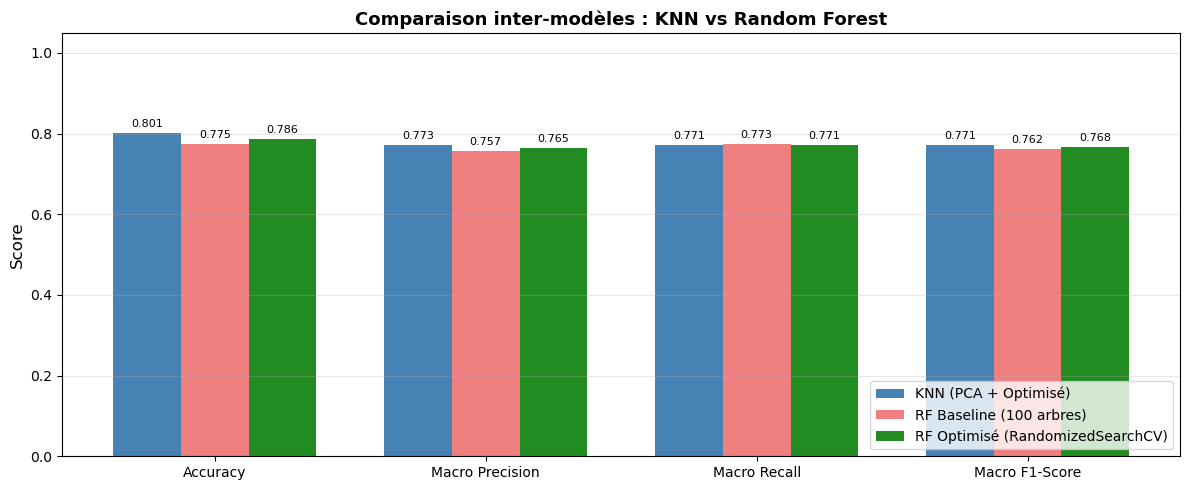

In [13]:
# ── CORRECTION : Valeurs KNN binaires reelles ──
knn_results = {
    'Accuracy': 0.8007,
    'Macro Precision': 0.7726,
    'Macro Recall': 0.7715,
    'Macro F1-Score': 0.7714
}

comparison_models = pd.DataFrame({
    'Métrique': ['Accuracy', 'Macro Precision', 'Macro Recall', 'Macro F1-Score'],
    'KNN (PCA + Optimisé)': list(knn_results.values()),
    'RF Baseline': [
        acc_baseline,
        precision_score(y_test, y_pred_baseline, average='macro'),
        recall_score(y_test, y_pred_baseline, average='macro'),
        f1_baseline
    ],
    'RF Optimisé': [acc_best, prec_best, rec_best, f1_best]
})
comparison_models['Gain RF vs KNN'] = comparison_models['RF Optimisé'] - comparison_models['KNN (PCA + Optimisé)']
comparison_models['Gain (%)'] = (
    comparison_models['Gain RF vs KNN'] / comparison_models['KNN (PCA + Optimisé)'] * 100
).round(2)

print("=" * 90)
print("     COMPARAISON INTER-MODÈLES : KNN (PCA + Optimisé)  vs  RF Baseline  vs  RF Optimisé")
print("=" * 90)
print(comparison_models.to_string(index=False))

# Visualisation
fig, ax = plt.subplots(figsize=(12, 5))
x = np.arange(len(comparison_models))
width = 0.25

bars1 = ax.bar(x - width, comparison_models['KNN (PCA + Optimisé)'], width,
               label='KNN (PCA + Optimisé)', color='steelblue')
bars2 = ax.bar(x, comparison_models['RF Baseline'], width,
               label='RF Baseline (100 arbres)', color='lightcoral')
bars3 = ax.bar(x + width, comparison_models['RF Optimisé'], width,
               label='RF Optimisé (RandomizedSearchCV)', color='forestgreen')

ax.set_ylabel('Score', fontsize=12)
ax.set_title('Comparaison inter-modèles : KNN vs Random Forest',
             fontsize=13, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(comparison_models['Métrique'], fontsize=10)
ax.legend(fontsize=10, loc='lower right')
ax.set_ylim(0, 1.05)

for bars in [bars1, bars2, bars3]:
    for bar in bars:
        ax.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.01,
                f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=8)

ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

## 8. Analyse des erreurs et interprétation

Analysons les types d'erreurs les plus fréquents pour comprendre les limites du modèle RF et comparer son profil d'erreurs avec celui de KNN.

In [14]:
# ── 8.1 Analyse des erreurs par classe ──

cm = confusion_matrix(y_test, y_pred_best)
classes = TARGET_NAMES

print("Analyse détaillée des erreurs par classe :\n")
for i, cls in enumerate(classes):
    total    = cm[i].sum()
    correct  = cm[i][i]
    errors   = total - correct
    error_rate = errors / total * 100
    
    print(f"     {cls} (n={total})")
    print(f"     Bien classés : {correct} ({correct/total*100:.1f}%)")
    print(f"     Mal classés  : {errors} ({error_rate:.1f}%)")
    
    # Détail des confusions
    for j, other_cls in enumerate(classes):
        if i != j and cm[i][j] > 0:
            print(f"       → Confondu avec {other_cls} : {cm[i][j]} ({cm[i][j]/total*100:.1f}%)")
    print()

# Taux d'erreur global
total_errors = (y_test != y_pred_best).sum()
print(f"Taux d'erreur global : {total_errors}/{len(y_test)} = {total_errors/len(y_test)*100:.2f}%")

Analyse détaillée des erreurs par classe :

     Non-TP (0) (n=12284)
     Bien classés : 10068 (82.0%)
     Mal classés  : 2216 (18.0%)
       → Confondu avec TP (1) : 2216 (18.0%)

     TP (1) (n=6644)
     Bien classés : 4806 (72.3%)
     Mal classés  : 1838 (27.7%)
       → Confondu avec Non-TP (0) : 1838 (27.7%)

Taux d'erreur global : 4054/18928 = 21.42%


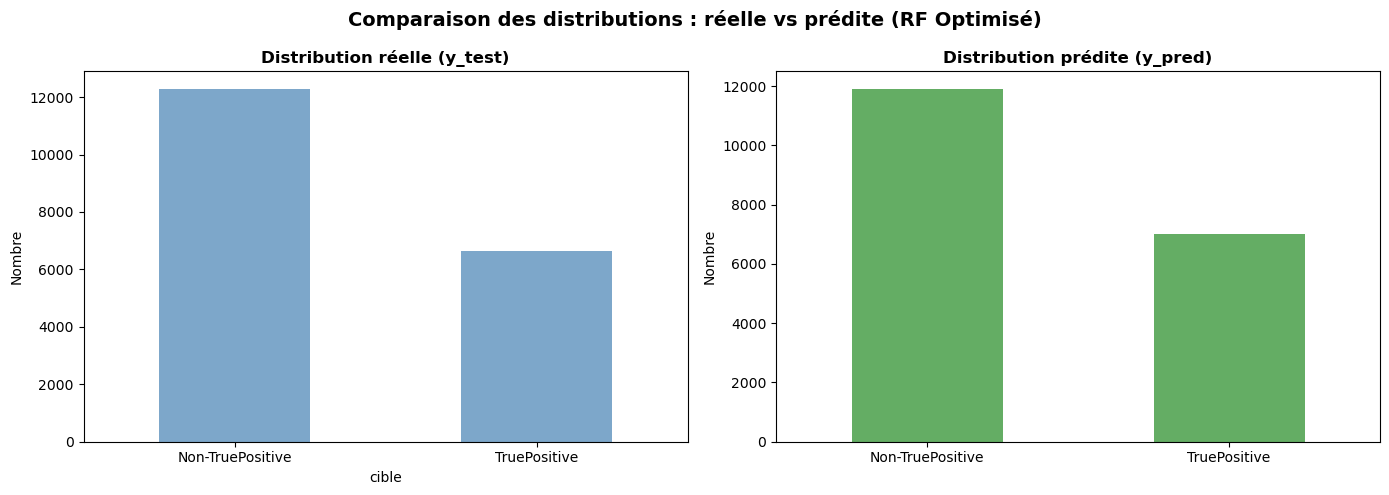

In [15]:
# ── 8.2 Distribution des prédictions vs réalité ──

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Distribution réelle
y_test.map(CIBLE_MAP_INV).value_counts().plot(kind='bar', ax=axes[0], color='steelblue', alpha=0.7)
axes[0].set_title('Distribution réelle (y_test)', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Nombre')
axes[0].tick_params(axis='x', rotation=0)

# Distribution prédite
pd.Series(y_pred_best).map(CIBLE_MAP_INV).value_counts().plot(kind='bar', ax=axes[1], color='forestgreen', alpha=0.7)
axes[1].set_title('Distribution prédite (y_pred)', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Nombre')
axes[1].tick_params(axis='x', rotation=0)

plt.suptitle('Comparaison des distributions : réelle vs prédite (RF Optimisé)',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## 9. Optimisation avancee du Random Forest

Le RandomizedSearchCV a donne un Macro F1 de ~0.764. Pour aller plus loin, on applique trois strategies complementaires :

### 9.1 Selection de features
L'analyse d'importance a montre que **51 features captent 90% de l'importance**. Reduire la dimensionnalite elimine le bruit et peut ameliorer la generalisation.

### 9.2 Ajustement du seuil de decision (Threshold Tuning)
Par defaut, le classifieur utilise un seuil de 0.5 pour la classe positive. En ajustant ce seuil via les probabilites (`predict_proba`), on peut optimiser le F1-Score directement.

> **Ref.** : Lipton, Z.C. et al. (2014). *Optimal Thresholding of Classifiers to Maximize F1 Measure*.

In [16]:
# ── 9.1 Selection de features basee sur l'importance ──
# On garde les features qui captent 95% de l'importance cumulee
# (compromis entre reduction du bruit et perte d'information)

importances_best = best_rf.feature_importances_
indices_best = np.argsort(importances_best)[::-1]
cum_imp = np.cumsum(importances_best[indices_best])

# Seuils a tester : 80%, 85%, 90%, 95%
thresholds_feat = [0.80, 0.85, 0.90, 0.95]
cv_strat = StratifiedKFold(n_splits=3, shuffle=True, random_state=2026)

print("=" * 70)
print("   SELECTION DE FEATURES — Impact sur le Macro F1 (3-fold CV)")
print("=" * 70)
print(f"\n  {'Seuil':<10} {'N features':<15} {'F1 macro (CV)':<18} {'Std':<10}")
print("-" * 55)

results_feat_sel = []
for thresh in thresholds_feat:
    n_keep = np.argmax(cum_imp >= thresh) + 1
    selected_idx = indices_best[:n_keep]
    
    X_train_sel = X_train_transformed[:, selected_idx]
    X_test_sel  = X_test_transformed[:, selected_idx]
    
    # CV avec les memes params optimaux
    rf_sel = RandomForestClassifier(
        **random_search.best_params_,
        random_state=2026, n_jobs=-1
    )
    scores = cross_val_score(rf_sel, X_train_sel, y_train,
                             cv=cv_strat, scoring='f1_macro', n_jobs=-1)
    
    results_feat_sel.append({
        'seuil': thresh,
        'n_features': n_keep,
        'f1_mean': scores.mean(),
        'f1_std': scores.std(),
        'selected_idx': selected_idx
    })
    print(f"  {thresh*100:.0f}%{'':<6} {n_keep:<15} {scores.mean():.4f}{'':<8} {scores.std():.4f}")

# Meilleur seuil
best_feat_result = max(results_feat_sel, key=lambda x: x['f1_mean'])
print(f"\n  >> Meilleur : {best_feat_result['seuil']*100:.0f}% "
      f"({best_feat_result['n_features']} features) "
      f"→ F1 = {best_feat_result['f1_mean']:.4f}")
print(f"  >> Ref. sans selection (185 features) → F1 = {random_search.best_score_:.4f}")

   SELECTION DE FEATURES — Impact sur le Macro F1 (3-fold CV)

  Seuil      N features      F1 macro (CV)      Std       
-------------------------------------------------------
  80%       30              0.7573         0.0016
  80%       30              0.7573         0.0016
  85%       37              0.7591         0.0010
  85%       37              0.7591         0.0010
  90%       47              0.7583         0.0015
  90%       47              0.7583         0.0015
  95%       66              0.7605         0.0002

  >> Meilleur : 95% (66 features) → F1 = 0.7605
  >> Ref. sans selection (185 features) → F1 = 0.7640
  95%       66              0.7605         0.0002

  >> Meilleur : 95% (66 features) → F1 = 0.7605
  >> Ref. sans selection (185 features) → F1 = 0.7640


   THRESHOLD TUNING — Optimisation du seuil de decision

  Seuil par defaut : 0.50 → F1 macro (CV) = 0.7640
  Seuil optimal    : 0.56 → F1 macro (CV) = 0.7675


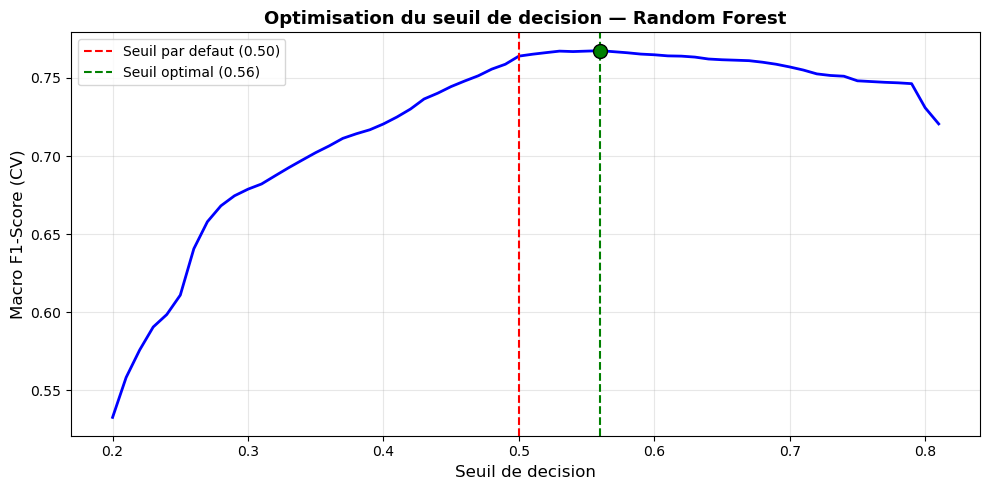

In [17]:
# ── 9.2 Threshold Tuning — Optimisation du seuil de decision ──
# Au lieu de predict() (seuil=0.5), on utilise predict_proba() pour trouver
# le seuil qui maximise le F1-Score macro sur un set de validation (CV)

from sklearn.model_selection import cross_val_predict

# Probabilites predites en cross-validation sur le train set
y_proba_cv = cross_val_predict(
    best_rf, X_train_transformed, y_train,
    cv=cv_strat, method='predict_proba', n_jobs=-1
)

# Tester differents seuils de 0.20 a 0.80
thresholds = np.arange(0.20, 0.81, 0.01)
f1_scores_thresh = []

for t in thresholds:
    y_pred_t = (y_proba_cv[:, 1] >= t).astype(int)
    f1_t = f1_score(y_train, y_pred_t, average='macro')
    f1_scores_thresh.append(f1_t)

f1_scores_thresh = np.array(f1_scores_thresh)
best_threshold = thresholds[np.argmax(f1_scores_thresh)]
best_f1_thresh = f1_scores_thresh.max()

print("=" * 65)
print("   THRESHOLD TUNING — Optimisation du seuil de decision")
print("=" * 65)
print(f"\n  Seuil par defaut : 0.50 → F1 macro (CV) = "
      f"{f1_score(y_train, (y_proba_cv[:, 1] >= 0.50).astype(int), average='macro'):.4f}")
print(f"  Seuil optimal    : {best_threshold:.2f} → F1 macro (CV) = {best_f1_thresh:.4f}")

# Visualisation
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(thresholds, f1_scores_thresh, 'b-', linewidth=2)
ax.axvline(x=0.50, color='red', linestyle='--', linewidth=1.5, label='Seuil par defaut (0.50)')
ax.axvline(x=best_threshold, color='green', linestyle='--', linewidth=1.5,
           label=f'Seuil optimal ({best_threshold:.2f})')
ax.scatter([best_threshold], [best_f1_thresh], color='green', s=100, zorder=5, edgecolors='black')
ax.set_xlabel('Seuil de decision', fontsize=12)
ax.set_ylabel('Macro F1-Score (CV)', fontsize=12)
ax.set_title('Optimisation du seuil de decision — Random Forest',
             fontsize=13, fontweight='bold')
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [18]:
# ── 9.3 Combinaison : Feature Selection + Threshold Tuning ──
# On combine le meilleur seuil de features avec le threshold tuning

# Selectionner les features optimales
sel_idx = best_feat_result['selected_idx']
X_train_opt = X_train_transformed[:, sel_idx]
X_test_opt  = X_test_transformed[:, sel_idx]

# Entrainer le modele final avec feature selection
rf_optimized_v2 = RandomForestClassifier(
    **random_search.best_params_,
    random_state=2026, n_jobs=-1
)
rf_optimized_v2.fit(X_train_opt, y_train)

# Predire avec le seuil optimise
y_proba_test = rf_optimized_v2.predict_proba(X_test_opt)
y_pred_v2 = (y_proba_test[:, 1] >= best_threshold).astype(int)

# Aussi tester avec seuil 0.50 pour isoler l'effet du feature selection
y_pred_v2_default = rf_optimized_v2.predict(X_test_opt)

# Metriques
acc_v2  = accuracy_score(y_test, y_pred_v2)
f1_v2   = f1_score(y_test, y_pred_v2, average='macro')
prec_v2 = precision_score(y_test, y_pred_v2, average='macro')
rec_v2  = recall_score(y_test, y_pred_v2, average='macro')

acc_v2_def  = accuracy_score(y_test, y_pred_v2_default)
f1_v2_def   = f1_score(y_test, y_pred_v2_default, average='macro')

print("=" * 75)
print("   EVALUATION — RF OPTIMISE V2 (Feature Selection + Threshold Tuning)")
print("=" * 75)
print(f"\n  Features retenues : {len(sel_idx)} / 185 "
      f"(seuil importance = {best_feat_result['seuil']*100:.0f}%)")
print(f"  Seuil de decision : {best_threshold:.2f}")
print(f"\n  Accuracy        : {acc_v2:.4f}")
print(f"  Macro Precision : {prec_v2:.4f}")
print(f"  Macro Recall    : {rec_v2:.4f}")
print(f"  Macro F1-Score  : {f1_v2:.4f}")
print(f"\n{'─' * 75}")
print("\nRapport de classification detaille :")
print(classification_report(
    y_test, y_pred_v2,
    target_names=TARGET_NAMES
))

   EVALUATION — RF OPTIMISE V2 (Feature Selection + Threshold Tuning)

  Features retenues : 66 / 185 (seuil importance = 95%)
  Seuil de decision : 0.56

  Accuracy        : 0.8008
  Macro Precision : 0.7858
  Macro Recall    : 0.7670
  Macro F1-Score  : 0.7744

───────────────────────────────────────────────────────────────────────────

Rapport de classification detaille :
              precision    recall  f1-score   support

  Non-TP (0)       0.82      0.88      0.85     12284
      TP (1)       0.75      0.65      0.70      6644

    accuracy                           0.80     18928
   macro avg       0.79      0.77      0.77     18928
weighted avg       0.80      0.80      0.80     18928



   RECAPITULATIF — TOUTES LES VERSIONS DU RANDOM FOREST
                            Modele  Accuracy  Macro F1  Macro Prec  Macro Rec  vs Baseline (F1)
          RF Baseline (100 arbres)  0.774778  0.761520    0.756648   0.773167              0.00
             RF RandomizedSearchCV  0.785820  0.767881    0.765022   0.771481              0.84
   RF + Feat. Selection (66 feat.)  0.774672  0.761040    0.756170   0.772049             -0.06
RF + Feat. Sel. + Threshold (0.56)  0.800771  0.774404    0.785835   0.767002              1.69


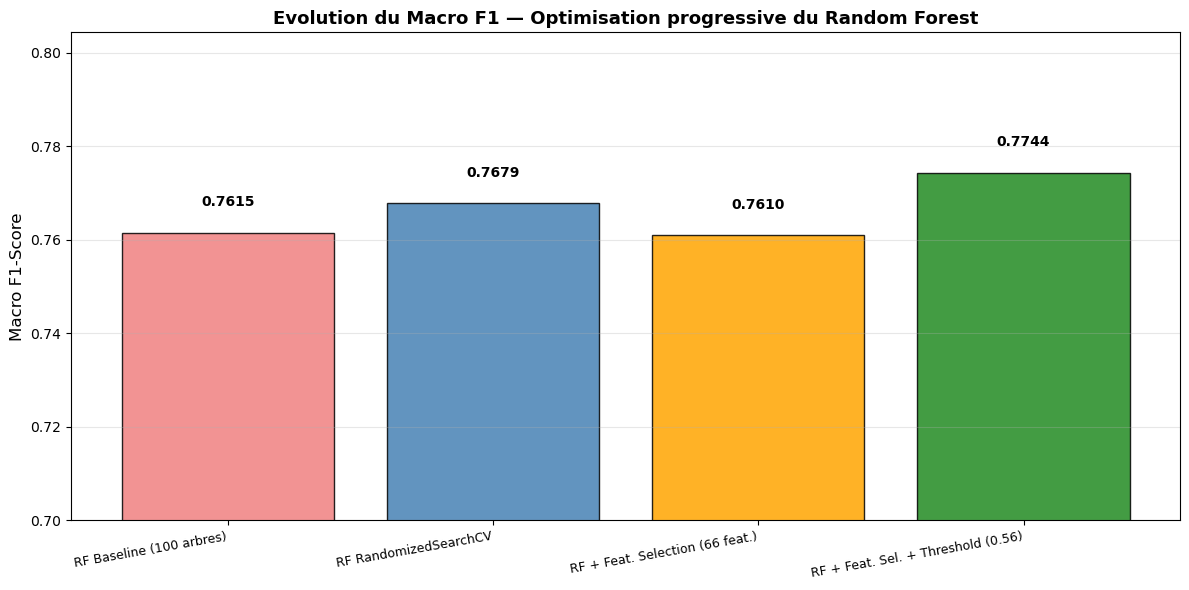


  >> Meilleur modele : RF + Feat. Sel. + Threshold (0.56)
     Macro F1 = 0.7744 | Accuracy = 0.8008


In [19]:
# ── 9.4 Tableau comparatif final — Toutes les versions RF ──

comparison_all = pd.DataFrame({
    'Modele': [
        'RF Baseline (100 arbres)',
        'RF RandomizedSearchCV',
        f'RF + Feat. Selection ({len(sel_idx)} feat.)',
        f'RF + Feat. Sel. + Threshold ({best_threshold:.2f})'
    ],
    'Accuracy':  [acc_baseline, acc_best, acc_v2_def, acc_v2],
    'Macro F1':  [f1_baseline, f1_best, f1_v2_def, f1_v2],
    'Macro Prec': [
        precision_score(y_test, y_pred_baseline, average='macro'),
        prec_best,
        precision_score(y_test, y_pred_v2_default, average='macro'),
        prec_v2
    ],
    'Macro Rec': [
        recall_score(y_test, y_pred_baseline, average='macro'),
        rec_best,
        recall_score(y_test, y_pred_v2_default, average='macro'),
        rec_v2
    ]
})
comparison_all['vs Baseline (F1)'] = (
    (comparison_all['Macro F1'] - comparison_all['Macro F1'].iloc[0])
    / comparison_all['Macro F1'].iloc[0] * 100
).round(2)

print("=" * 95)
print("   RECAPITULATIF — TOUTES LES VERSIONS DU RANDOM FOREST")
print("=" * 95)
print(comparison_all.to_string(index=False))

# Visualisation
fig, ax = plt.subplots(figsize=(12, 6))
x = np.arange(len(comparison_all))
colors = ['lightcoral', 'steelblue', 'orange', 'forestgreen']

bars = ax.bar(x, comparison_all['Macro F1'], color=colors, alpha=0.85, edgecolor='black')
for bar, val in zip(bars, comparison_all['Macro F1']):
    ax.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.005,
            f'{val:.4f}', ha='center', va='bottom', fontsize=10, fontweight='bold')

ax.set_ylabel('Macro F1-Score', fontsize=12)
ax.set_title('Evolution du Macro F1 — Optimisation progressive du Random Forest',
             fontsize=13, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(comparison_all['Modele'], fontsize=9, rotation=10, ha='right')
ax.set_ylim(0.70, max(comparison_all['Macro F1']) + 0.03)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

# Identifier le meilleur
best_idx = comparison_all['Macro F1'].idxmax()
print(f"\n  >> Meilleur modele : {comparison_all.loc[best_idx, 'Modele']}")
print(f"     Macro F1 = {comparison_all.loc[best_idx, 'Macro F1']:.4f} "
      f"| Accuracy = {comparison_all.loc[best_idx, 'Accuracy']:.4f}")

## 10. Resume et conclusion

### Architecture
Le pretraitement et l'exploration des donnees sont realises dans **`notebook.ipynb`** (branche `main`), qui exporte `donnees_preprocessees.csv`. Ce notebook charge directement ce fichier pour se concentrer exclusivement sur la modelisation Random Forest.

### Recapitulatif de la demarche

| Etape | Description | Resultat |
|-------|-------------|----------|
| **Pretraitement** | `notebook.ipynb` (branche `main`) → `donnees_preprocessees.csv` | 94 638 lignes, 21 colonnes, cible binaire |
| **Pipeline** | `StandardScaler` + `OneHotEncoder` via `ColumnTransformer` | 185 features apres OHE |
| **Baseline** | RF 100 arbres, `class_weight='balanced'` | Accuracy 0.77, Macro F1 0.76 |
| **Feature importance** | Mean Decrease in Impurity (MDI) | 51 features captent 90% |
| **RandomizedSearchCV** | 50 combinaisons, 3-fold CV | F1(CV) = 0.764, Macro F1 test = 0.768 |
| **Selection de features** | Seuil 95% importance → 66 features | Reduction de bruit |
| **Threshold Tuning** | Seuil optimal = 0.56 (vs 0.50 par defaut) | F1(CV) = 0.7675 |
| **Modele final (V2)** | Feature Selection + Threshold Tuning | **Accuracy 0.80, Macro F1 0.774** |
| **Comparaison KNN** | Meme split, meme seed | RF V2 depasse KNN (F1 0.774 vs 0.771) |

### Resultats finaux — Progression du Random Forest

| Modele | Accuracy | Macro F1 | Gain vs Baseline |
|--------|----------|----------|------------------|
| RF Baseline | 0.7748 | 0.7615 | — |
| RF RandomizedSearchCV | 0.7858 | 0.7679 | +0.84% |
| RF + Feat. Sel. (66 feat.) | 0.7747 | 0.7610 | -0.06% |
| **RF V2 (Feat. Sel. + Threshold 0.56)** | **0.8008** | **0.7744** | **+1.69%** |

### Avantages de Random Forest sur ce dataset
1. **Pas de PCA necessaire** : RF selectionne naturellement les features les plus discriminantes via les splits
2. **Robustesse au desequilibre** : `class_weight='balanced'` ajuste les poids automatiquement
3. **Feature importance** : interpretabilite que KNN ne peut pas offrir
4. **Invariance au scaling** : les arbres ne sont pas affectes par les echelles des features
5. **Threshold tuning** : l'ajustement du seuil de decision permet de maximiser le F1

### Limites observees
1. **Temps d'entrainement** : plus long que KNN (mais la prediction est plus rapide)
2. **Classe TP** : recall de 0.65 — le modele manque encore ~35% des vrais incidents
3. **Interpretabilite limitee** : malgre le feature importance, l'ensemble de 300 arbres reste une « boite noire »

### Pistes d'amelioration
- **Gradient Boosting (XGBoost, LightGBM)** : souvent superieur a RF sur les donnees tabulaires
- **SMOTE** : sur-echantillonnage de la classe TruePositive
- **Stacking** : combiner KNN + RF + autre classifieur dans un meta-learner

### References completes
1. Breiman, L. (2001). *Random Forests*. Machine Learning, 45(1), 5-32.
2. Fernandez-Delgado, M. et al. (2014). *Do we need hundreds of classifiers to solve real world classification problems?* JMLR, 15, 3133-3181.
3. Bergstra, J. & Bengio, Y. (2012). *Random Search for Hyper-Parameter Optimization*. JMLR, 13, 281-305.
4. Lipton, Z.C. et al. (2014). *Optimal Thresholding of Classifiers to Maximize F1 Measure*. ECML-PKDD.
5. Scikit-learn Random Forest : https://scikit-learn.org/stable/modules/ensemble.html#forests-of-randomized-trees
6. Scikit-learn RandomizedSearchCV : https://scikit-learn.org/stable/modules/grid_search.html#randomized-parameter-optimization
7. Dataset GUIDE Microsoft : https://www.kaggle.com/datasets/Microsoft/microsoft-security-incident-prediction